# Лабораторна робота №2
## Тема: NumPy, pandas і Matplotlib для підготовки, аналізу та візуалізації даних

**Студент:** Адамчук Ярослав  
**Група:** МІТ 31  
**Номер у списку (Варіант):** 2  
**Предметна область:** Мережевий трафік (X — Час, хв; Y — Обсяг, МБ)  
**Параметри моделі:** a = 2.4, b = 35.0, σ = 5.0, seed = 2

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy версія:", np.__version__)
print("pandas версія:", pd.__version__)

NumPy версія: 2.5.3
pandas версія: 3.0.6


In [14]:
seed = 2
a = 2.4
b = 35.0
sigma = 5.0

# 1. Генератор випадкових чисел
rng = np.random.default_rng(seed)

# 2. Масив x: 100 рівномірних точок від 0 до 20
x = np.linspace(0, 20, 100)

# 3. Обчислення y_hat, шуму та y_observed
y_hat = a * x + b
noise = rng.normal(loc=0.0, scale=sigma, size=x.size)
y_observed = y_hat + noise

# 4. Об'єднання у двовимірну матрицю
matrix = np.column_stack((x, y_hat, noise, y_observed))

print("Форма (shape):", matrix.shape)
print("Кількість вимірів (ndim):", matrix.ndim)
print("Загальна кількість елементів (size):", matrix.size)
print("Тип даних (dtype):", matrix.dtype)
print("\nПерші 3 рядки матриці:\n", matrix[:3])

Форма (shape): (100, 4)
Кількість вимірів (ndim): 2
Загальна кількість елементів (size): 400
Тип даних (dtype): float64

Перші 3 рядки матриці:
 [[ 0.         35.          0.94526691 35.94526691]
 [ 0.2020202  35.48484848 -2.61374221 32.87110628]
 [ 0.4040404  35.96969697 -2.06531772 33.90437925]]


### Пояснення структури масиву:
* **shape (100, 4)** означає, що матриця містить 100 спостережень (рядків) та 4 показники (стовпці: `x`, `y_hat`, `noise`, `y_observed`).
* **ndim = 2** вказує на двовимірність структури.
* **size = 400** — сумарна кількість значень у матриці (100 * 4).
* **dtype = float64** показує, що всі елементи є дійсними числами подвійної точності.

In [15]:
# Читання окремого елемента та зрізу
print("Елемент [0, 0]:", matrix[0, 0])
print("Зріз перших 3 значень y_observed:", matrix[:3, 3])

# Булева фільтрація: виміри, де обсяг трафіку перевищує 70 МБ
high_traffic = matrix[matrix[:, 3] > 70]
print(f"Кількість вимірів із трафіком > 70 МБ: {len(high_traffic)}")

# Робота з копією фрагмента (copy vs view)
fragment_copy = matrix[:5, :].copy()
fragment_copy[0, 3] = 999.0
print("Значення в копії після оновлення:", fragment_copy[0, 3])
print("Оригінальне значення в matrix (не змінилося завдяки copy):", matrix[0, 3])

# Видалення першого рядка з копії масиву
reduced_matrix = np.delete(matrix, 0, axis=0)
print("Форма після видалення рядка:", reduced_matrix.shape)

Елемент [0, 0]: 0.0
Зріз перших 3 значень y_observed: [35.94526691 32.87110628 33.90437925]
Кількість вимірів із трафіком > 70 МБ: 28
Значення в копії після оновлення: 999.0
Оригінальне значення в matrix (не змінилося завдяки copy): 35.94526690896767
Форма після видалення рядка: (99, 4)


In [16]:
print("--- Статистика y_observed ---")
print(f"Мінімум: {np.min(y_observed):.2f} МБ")
print(f"Максимум: {np.max(y_observed):.2f} МБ")
print(f"Середнє: {np.mean(y_observed):.2f} МБ")
print(f"Стандартне відхилення: {np.std(y_observed):.2f} МБ")

# Агрегація за axis=0 (середнє для кожного з 4 стовпців)
column_means = np.mean(matrix, axis=0)
print("\nСередні значення стовпців (x, y_hat, noise, y_observed) через axis=0:")
print(column_means)

--- Статистика y_observed ---
Мінімум: 24.25 МБ
Максимум: 85.78 МБ
Середнє: 58.96 МБ
Стандартне відхилення: 14.47 МБ

Середні значення стовпців (x, y_hat, noise, y_observed) через axis=0:
[ 1.0000000e+01  5.9000000e+01 -4.2096998e-02  5.8957903e+01]


### Висновок по блоку NumPy
Використання векторних обчислень NumPy дозволило згенерувати залежність без явних циклів. Параметр `axis=0` виконує агрегацію по стовпцях, обчислюючи окреме значення для кожної змінної. Застосування `.copy()` захистило вихідний масив від ненавмисних змін.

In [17]:
# 1. Формування DataFrame
df = pd.DataFrame({
    "x": x,
    "y_true": y_hat,
    "noise": noise,
    "y_observed": y_observed
})

# Розбиття значень X на 3 рівні інтервали: low, medium, high
df["group"] = pd.qcut(df["x"], q=3, labels=["low", "medium", "high"])

print("Перші 5 рядків DataFrame:")
display(df.head())

Перші 5 рядків DataFrame:


,x,y_true,noise,y_observed,group
0,0.000000,35.000000,0.945267,35.945267,low
1,0.202020,35.484848,-2.613742,32.871106,low
2,0.404040,35.969697,-2.065318,33.904379,low
3,0.606061,36.454545,-12.207337,24.247209,low
4,0.808081,36.939394,8.998537,45.937931,low


In [18]:
print("Форма таблиці (shape):", df.shape)
print("\nТипи даних стовпців (dtypes):\n", df.dtypes)
print("\nЗагальна інформація про DataFrame (info):")
df.info()

print("\nОписова статистика числових стовпців (describe):")
display(df.describe())

Форма таблиці (shape): (100, 5)

Типи даних стовпців (dtypes):
 x              float64
y_true         float64
noise          float64
y_observed     float64
group         category
dtype: object

Загальна інформація про DataFrame (info):
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   x           100 non-null    float64 
 1   y_true      100 non-null    float64 
 2   noise       100 non-null    float64 
 3   y_observed  100 non-null    float64 
 4   group       100 non-null    category
dtypes: category(1), float64(4)
memory usage: 3.5 KB

Описова статистика числових стовпців (describe):


,x,y_true,noise,y_observed
count,100.000000,100.000000,100.000000,100.000000
mean,10.000000,59.000000,-0.042097,58.957903
std,5.860907,14.066178,4.780607,14.544807
min,0.000000,35.000000,-12.207337,24.247209
25%,5.000000,47.000000,-3.465058,47.020140
50%,10.000000,59.000000,-0.213862,60.365415
75%,15.000000,71.000000,3.340050,71.991034
max,20.000000,83.000000,11.874435,85.779084


In [19]:
# Працюємо з явною копією для очищення
df_clean = df.copy()

# Штучно додаємо щонайменше 3 пропуски у стовпець y_observed
df_clean.loc[[10, 25, 50], "y_observed"] = np.nan

# Штучно дублюємо перший рядок і додаємо в кінець таблиці
df_clean = pd.concat([df_clean, df_clean.iloc[[0]]], ignore_index=True)

print("Форма таблиці після додавання пропусків і дубліката:", df_clean.shape)
print("\nКількість пропусків у стовпцях:\n", df_clean.isna().sum())
print("\nКількість повних дублікатів рядків:", df_clean.duplicated().sum())

Форма таблиці після додавання пропусків і дубліката: (101, 5)

Кількість пропусків у стовпцях:
 x             0
y_true        0
noise         0
y_observed    3
group         0
dtype: int64

Кількість повних дублікатів рядків: 1


In [20]:
# Видалення дублікатів
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Форма після видалення дублікатів:", df_clean.shape)

# Заповнення пропусків медіаною
median_value = df_clean["y_observed"].median()
df_clean["y_observed"] = df_clean["y_observed"].fillna(median_value)

print(f"Пропуски заповнено медіаною: {median_value:.2f} МБ")
print("Залишок пропусків після обробки:\n", df_clean.isna().sum())

Форма після видалення дублікатів: (100, 5)
Пропуски заповнено медіаною: 60.98 МБ
Залишок пропусків після обробки:
 x             0
y_true        0
noise         0
y_observed    0
group         0
dtype: int64


### Обґрунтування заповнення пропусків медіаною:
Для заповнення пропусків обрано медіану (`median`), оскільки вона, на відміну від середнього арифметичного (`mean`), є стійкою (робастною) оцінкою центральної тенденції. Медіана не зміщується під впливом аномальних викидів (екстремальних сплесків трафіку чи випадкового шуму).

In [21]:
# Доступ за мітками (loc): рядки 0-3 та обрані стовпці
print("Приклад loc:\n", df_clean.loc[0:3, ["x", "y_observed", "group"]])

# Доступ за позиціями (iloc): перші 3 рядки та перші 2 стовпці
print("\nПриклад iloc:\n", df_clean.iloc[0:3, 0:2])

# Булева фільтрація: вибірка з групи 'high' із трафіком > 75 МБ
filtered_df = df_clean[(df_clean["group"] == "high") & (df_clean["y_observed"] > 75)]
print(f"\nКількість рядків після фільтрації (high та > 75 МБ): {len(filtered_df)}")

# Сортування: за спаданням фактичного трафіку (топ-3 найбільших значень)
sorted_top3 = df_clean.sort_values(by="y_observed", ascending=False).head(3)
print("\nТоп-3 спостереження за максимальним трафіком:\n", sorted_top3[["x", "y_observed", "group"]])

Приклад loc:
           x  y_observed group
0  0.000000   35.945267   low
1  0.202020   32.871106   low
2  0.404040   33.904379   low
3  0.606061   24.247209   low

Приклад iloc:
          x     y_true
0  0.00000  35.000000
1  0.20202  35.484848
2  0.40404  35.969697

Кількість рядків після фільтрації (high та > 75 МБ): 17

Топ-3 спостереження за максимальним трафіком:
             x  y_observed group
90  18.181818   85.779084  high
88  17.777778   83.312805  high
95  19.191919   81.297628  high


In [22]:
# Групування за інтервалами: середнє, стандартне відхилення та кількість через size()
summary_table = df_clean.groupby("group", observed=False).agg(
    mean_traffic=("y_observed", "mean"),
    std_traffic=("y_observed", "std"),
    total_count=("y_observed", "size")
).reset_index()

print("Агрегована таблиця за групами:")
display(summary_table)

Агрегована таблиця за групами:


,group,mean_traffic,std_traffic,total_count
0,low,43.844289,8.195469,34
1,medium,59.514859,6.535675,33
2,high,74.661940,6.028056,33


### Відмінність між `size()` та `count()` у pandas:
* **`count()`** підраховує лише валідні (непорожні, не-`NaN`) значення у кожному стовпці групи.
* **`size()`** підраховує повну кількість рядків у групі незалежно від наявності пропущених значень (`NaN`).

In [23]:
# 1. Ручний розрахунок метрик засобами NumPy
y_obs = df_clean["y_observed"].to_numpy()
y_tr = df_clean["y_true"].to_numpy()

mae = np.mean(np.abs(y_obs - y_tr))
mse = np.mean((y_obs - y_tr) ** 2)

print(f"MAE (Середня абсолютна похибка): {mae:.4f} МБ")
print(f"MSE (Середня квадратична похибка): {mse:.4f} МБ²")

# 2. Додавання стовпців похибок до DataFrame
df_clean["absolute_error"] = np.abs(df_clean["y_observed"] - df_clean["y_true"])
df_clean["squared_error"] = (df_clean["y_observed"] - df_clean["y_true"]) ** 2

display(df_clean[["x", "y_true", "y_observed", "absolute_error", "squared_error"]].head())

MAE (Середня абсолютна похибка): 4.0276 МБ
MSE (Середня квадратична похибка): 28.3837 МБ²


,x,y_true,y_observed,absolute_error,squared_error
0,0.000000,35.000000,35.945267,0.945267,0.893530
1,0.202020,35.484848,32.871106,2.613742,6.831648
2,0.404040,35.969697,33.904379,2.065318,4.265537
3,0.606061,36.454545,24.247209,12.207337,149.019075
4,0.808081,36.939394,45.937931,8.998537,80.973667


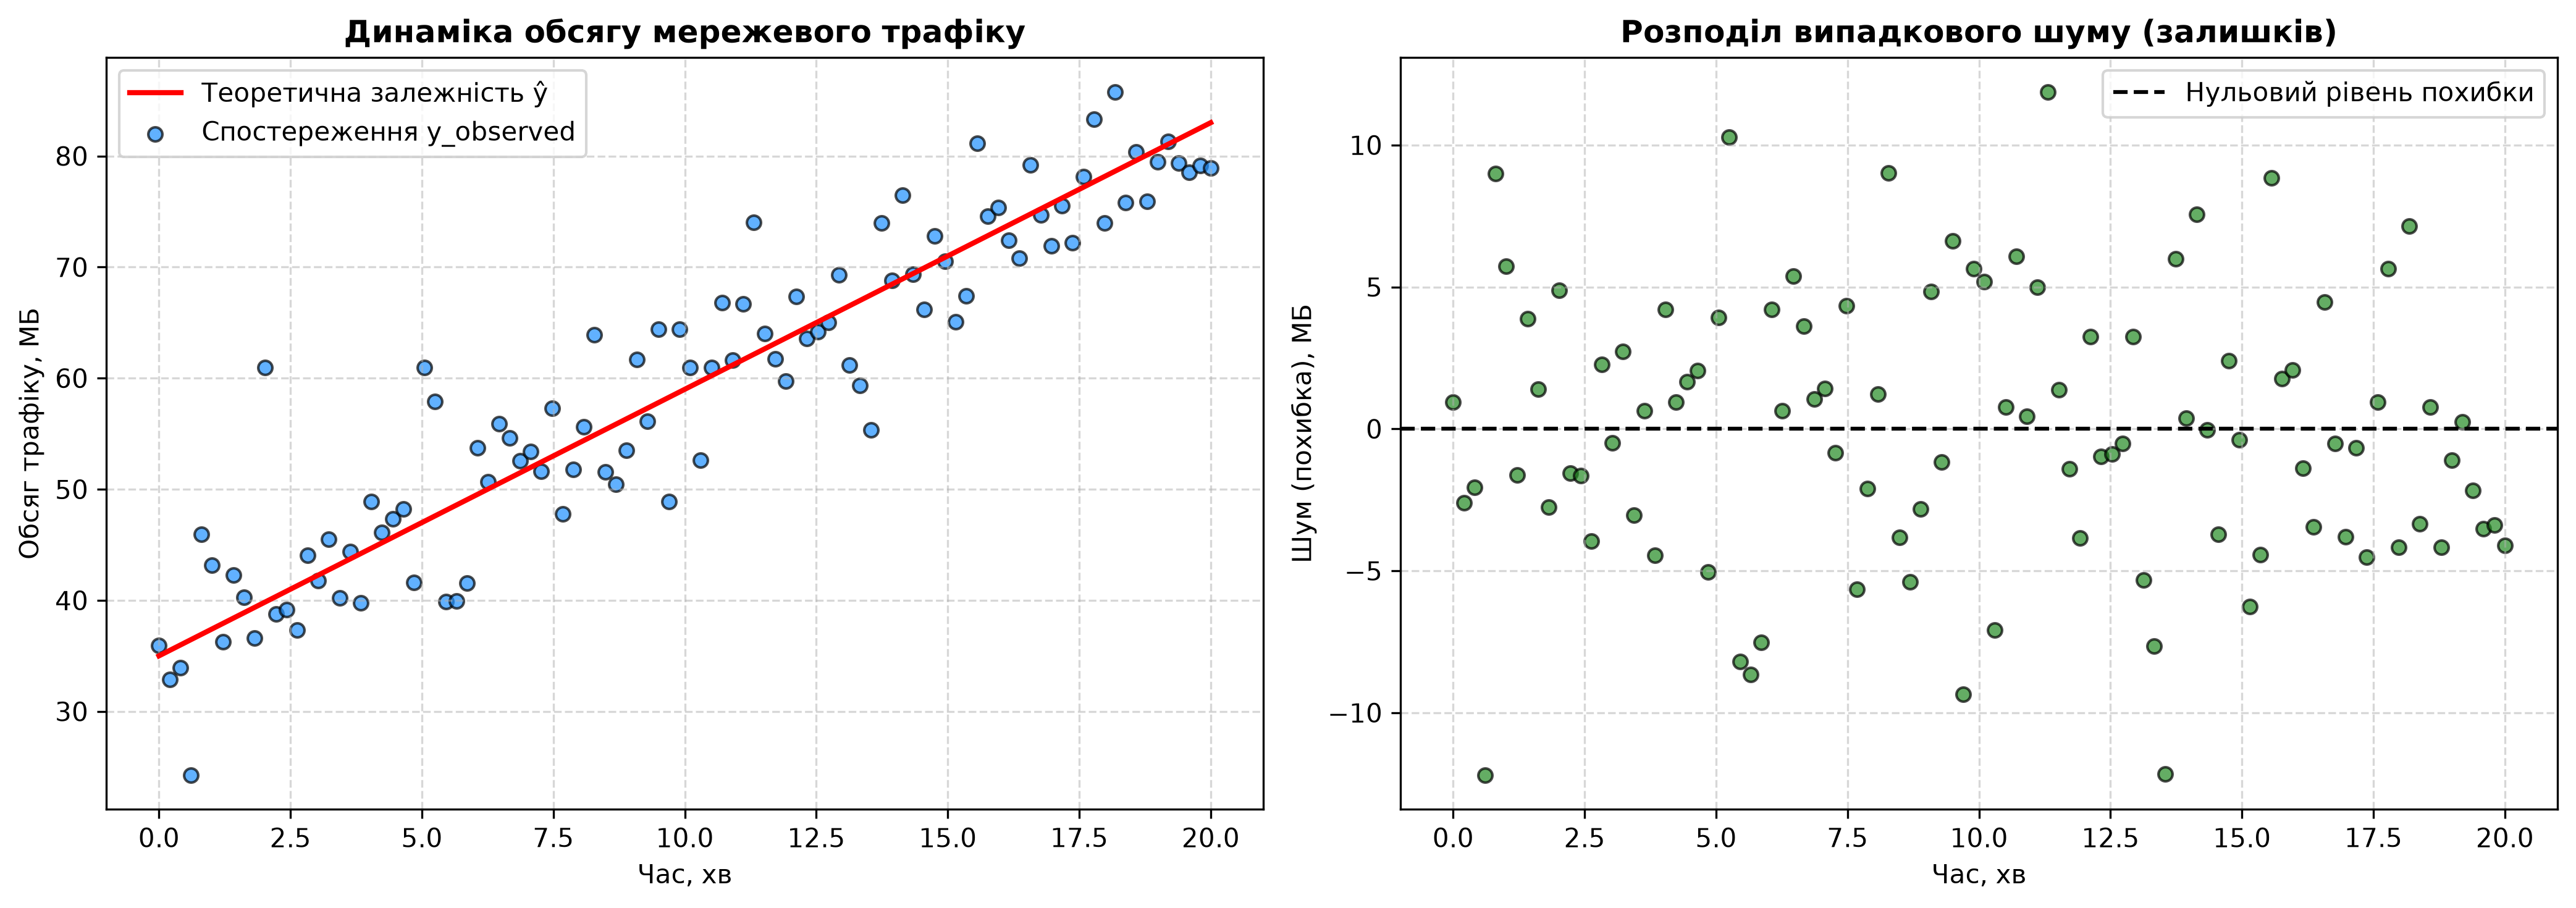

In [24]:
# Створення рисунка з двома підграфіками через об'єктний інтерфейс fig, ax
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), dpi=300)

# Графік 1: Лінія тренду y_true та точки спостережень y_observed
ax1.plot(df_clean["x"], df_clean["y_true"], color="red", linewidth=2, label="Теоретична залежність ŷ")
ax1.scatter(df_clean["x"], df_clean["y_observed"], color="dodgerblue", alpha=0.7, edgecolors="k", s=30, label="Спостереження y_observed")
ax1.set_title("Динаміка обсягу мережевого трафіку", fontsize=12, fontweight="bold")
ax1.set_xlabel("Час, хв", fontsize=10)
ax1.set_ylabel("Обсяг трафіку, МБ", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")

# Графік 2: Діаграма залишків шуму відносно X
ax2.scatter(df_clean["x"], df_clean["noise"], color="forestgreen", alpha=0.7, edgecolors="k", s=30)
ax2.axhline(0, color="black", linestyle="--", linewidth=1.5, label="Нульовий рівень похибки")
ax2.set_title("Розподіл випадкового шуму (залишків)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Час, хв", fontsize=10)
ax2.set_ylabel("Шум (похибка), МБ", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right")

plt.tight_layout()

# Збереження графіка у файл з високою якістю
fig.savefig("Lab2_traffic_plot.png", dpi=300)
plt.show()

In [25]:
# 1. Збереження очищеного DataFrame у CSV та Parquet
df_clean.to_csv("Lab2_results.csv", index=False)
df_clean.to_parquet("Lab2_results.parquet", index=False)

# 2. Збереження агрегованої таблиці у CSV
summary_table.to_csv("Lab2_summary.csv", index=False)

# 3. Контрольне зчитування збереженого CSV та перевірка розмірності
df_reloaded = pd.read_csv("Lab2_results.csv")
print(f"Форма вихідного DataFrame: {df_clean.shape}")
print(f"Форма зчитаного CSV: {df_reloaded.shape}")
assert df_clean.shape == df_reloaded.shape, "Помилка: розмірності не збігаються!"
print("Перевірка успішна: збережений файл відповідає вихідним даним.")

Форма вихідного DataFrame: (100, 7)
Форма зчитаного CSV: (100, 7)
Перевірка успішна: збережений файл відповідає вихідним даним.


## Загальний висновок

У ході лабораторної роботи №2 було практично опановано стек бібліотек аналізу даних Python: **NumPy**, **pandas** та **Matplotlib**:
1. За допомогою **NumPy** згенеровано 100 відліків мережевого трафіку за варіантом №2 ($a = 2.4$, $b = 35.0$, $\sigma = 5.0$, seed = 2). Застосовано векторні операції, зрізи, булеву фільтрацію та агрегацію по стовпцях (`axis=0`).
2. Засобами **pandas** сформовано DataFrame, проведено первинну діагностику (`info()`, `describe()`), оброблено штучно додані пропуски шляхом заповнення робастною оцінкою — медіаною, а також видалено дублікати. Здійснено агрегацію за діапазонами значень через `groupby()`.
3. Розраховано метрики відхилень:
   * **MAE** показує середнє лінійне відхилення спостережень від істинного тренду в одиницях цільової величини (МБ).
   * **MSE** виражається у квадратичних одиницях (МБ²) та є чутливою до великих похибок через зведення залишків у квадрат. Обидві величини є строго невід'ємними.
4. Побудовано графіки через об'єктний інтерфейс `plt.subplots()` із підписами осей, одиницями вимірювання та сіткою. Дані успішно експортовано у формати CSV, Parquet та рисунок PNG із роздільною здатністю 300 DPI.